In [58]:
import numpy as np
import struct
import matplotlib.pyplot as plt


def load_images(filename):
    with open(filename, 'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        rows, cols = struct.unpack(">II", f.read(8))

        data = np.fromfile(f, dtype = np.uint8)
        data = data.reshape(size, rows, cols)

        return data
    
images = load_images("train-images-idx3-ubyte")

print(images.shape)


(60000, 28, 28)


In [59]:
def load_labels(filename):
    with open(filename, 'rb') as f:
        magic, size = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype = np.uint8, count=size)
        return labels

labels = load_labels("train-labels-idx1-ubyte")

print(labels.shape)
print(labels[:10])

(60000,)
[5 0 4 1 9 2 1 3 1 4]


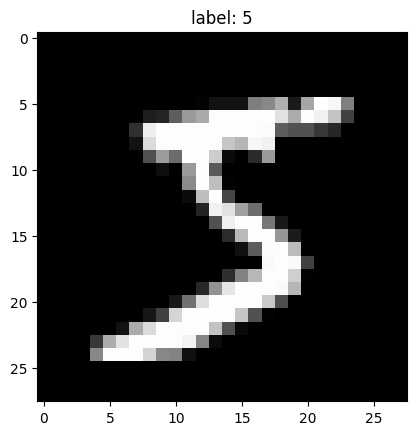

In [60]:
plt.imshow(images[0], cmap='gray')
plt.title(f"label: {labels[0]}")
plt.show()

In [61]:
images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [62]:
X = images.reshape(60000, 28*28)
X.shape

(60000, 784)

Show the First 20 Pixels of the first image

In [63]:
X[0][:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=uint8)

Normalize the pixels values for easy machine learning and gradient descent

In [64]:
X = X/255.0

In [65]:
X[0][180:300]

array([0.66666667, 0.99215686, 0.99215686, 0.99215686, 0.99215686,
       0.99215686, 0.88235294, 0.6745098 , 0.99215686, 0.94901961,
       0.76470588, 0.25098039, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.19215686, 0.93333333,
       0.99215686, 0.99215686, 0.99215686, 0.99215686, 0.99215686,
       0.99215686, 0.99215686, 0.99215686, 0.98431373, 0.36470588,
       0.32156863, 0.32156863, 0.21960784, 0.15294118, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.07058824, 0.85882353, 0.99215686, 0.99215686,
       0.99215686, 0.99215686, 0.99215686, 0.77647059, 0.71372549,
       0.96862745, 0.94509804, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [66]:
labels[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

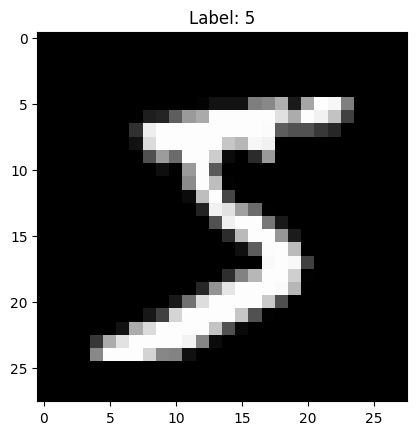

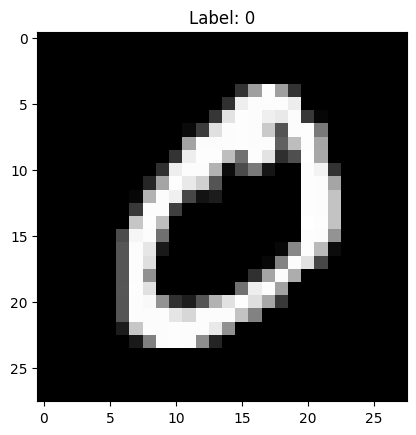

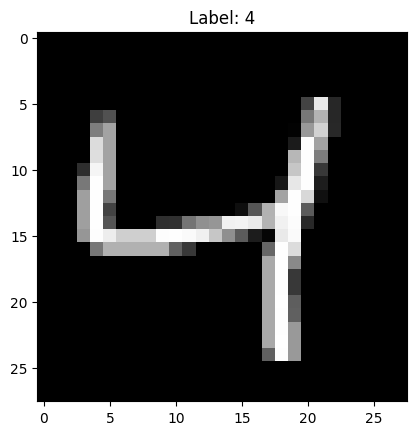

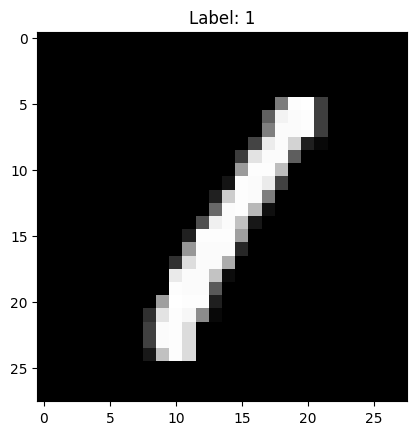

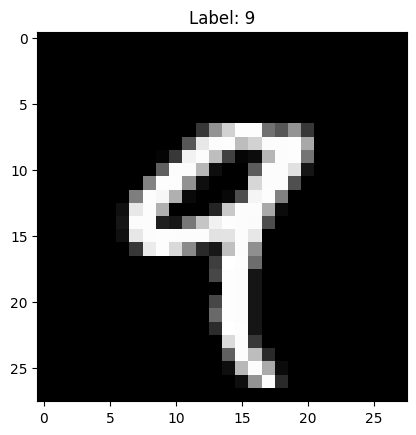

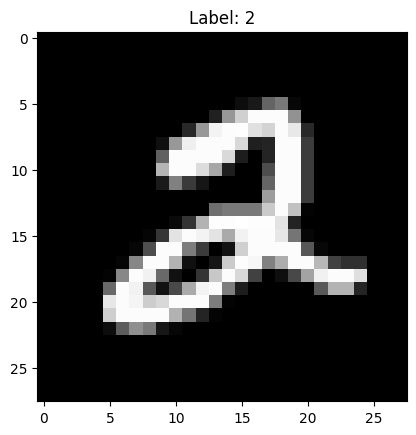

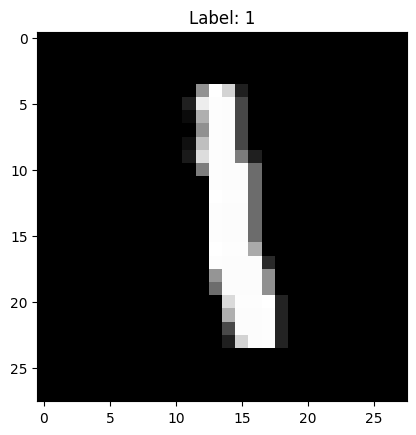

In [67]:
for i in range(0,7):
    plt.imshow(images[i], cmap = 'gray')
    plt.title(f"Label: {labels[i]}")
    plt.show()

In [68]:
print(images.shape)
print(labels.shape)

(60000, 28, 28)
(60000,)


In [69]:
X_train = X[:50000]
y_train = labels[:50000]

X_test = X[50000:]
y_test = labels[50000:]

In [70]:
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]


Y_train = one_hot(y_train)
Y_test = one_hot(y_test)

In [71]:
input_size = 784
hidden_size = 64
output_size = 10

In [72]:
np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

In [73]:
def relu(x):
    return np.maximum(0, x)


def softmax(x):
    exp = np.exp(x - np.max(x, axis = 1, keepdims = True))
    return exp/ np.sum(exp, axis = 1, keepdims = True)

In [74]:
Z1 = X_train @ W1 + b1
A1 = relu(Z1)

Z2 = A1 @ W2 + b2
Y_pred = softmax(Z2)

In [75]:
def compute_loss(Y_pred, Y_true):
    return -np.mean(np.sum(Y_true * np.log(Y_pred + 1e-8), axis =1))

In [76]:
loss = compute_loss(Y_pred, Y_train)
loss

np.float64(2.3026802115722314)

Here, we begin Backprop

In [77]:
dZ2 = Y_pred - Y_train

In [78]:
dW2 = A1.T @ dZ2 / X_train.shape[0]
db2 = np.sum(dZ2, axis=0, keepdims=True) / X_train.shape[0]

In [79]:
dA1 = dZ2 @ W2.T
dZ1 =dA1 * (Z1 > 0)

In [80]:
dW1 = X_train.T @ dZ1 / X_train.shape[0]
db1 = np.sum(dZ1, axis=0, keepdims=True) / X_train.shape[0]

In [81]:
learning_rate = 0.1
W2 -= learning_rate * dW2
b2 -= learning_rate * db2

W1 -= learning_rate * dW1
b1 -= learning_rate * db1

In [82]:
epochs = 10000 
for epoch in range(epochs):

    #Forward
    Z1 = X_train @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    Y_pred = softmax(Z2)

    # Loss
    loss = compute_loss(Y_pred, Y_train)

    # Backward
    dZ2 = Y_pred - Y_train
    dW2 = A1.T @ dZ2 / X_train.shape[0]
    db2 = np.sum(dZ2, axis=0, keepdims=True) / X_train.shape[0]

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 *  (Z1 > 0)

    dW1 = X_train.T @ dZ1 / X_train.shape[0]
    db1 = np.sum(dZ1, axis =0, keepdims=True) / X_train.shape[0]

    # Update
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 1 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 2.3021
Epoch 1, Loss: 2.3015
Epoch 2, Loss: 2.3010
Epoch 3, Loss: 2.3004
Epoch 4, Loss: 2.2998
Epoch 5, Loss: 2.2991
Epoch 6, Loss: 2.2985
Epoch 7, Loss: 2.2978
Epoch 8, Loss: 2.2970
Epoch 9, Loss: 2.2963
Epoch 10, Loss: 2.2954
Epoch 11, Loss: 2.2946
Epoch 12, Loss: 2.2936
Epoch 13, Loss: 2.2926
Epoch 14, Loss: 2.2916
Epoch 15, Loss: 2.2904
Epoch 16, Loss: 2.2892
Epoch 17, Loss: 2.2878
Epoch 18, Loss: 2.2864
Epoch 19, Loss: 2.2849
Epoch 20, Loss: 2.2832
Epoch 21, Loss: 2.2814
Epoch 22, Loss: 2.2794
Epoch 23, Loss: 2.2773
Epoch 24, Loss: 2.2750
Epoch 25, Loss: 2.2726
Epoch 26, Loss: 2.2699
Epoch 27, Loss: 2.2670
Epoch 28, Loss: 2.2639
Epoch 29, Loss: 2.2605
Epoch 30, Loss: 2.2568
Epoch 31, Loss: 2.2529
Epoch 32, Loss: 2.2486
Epoch 33, Loss: 2.2440
Epoch 34, Loss: 2.2390
Epoch 35, Loss: 2.2337
Epoch 36, Loss: 2.2280
Epoch 37, Loss: 2.2218
Epoch 38, Loss: 2.2152
Epoch 39, Loss: 2.2081
Epoch 40, Loss: 2.2005
Epoch 41, Loss: 2.1924
Epoch 42, Loss: 2.1838
Epoch 43, Loss: 2.174

In [83]:
y_pred_classes = np.argmax(Y_pred, axis = 1)
y_true_classes = np.argmax(Y_train, axis = 1)

In [84]:
accuracy =  np.mean(y_pred_classes == y_true_classes)
print(f"Training Accuracy: {accuracy}")

Training Accuracy: 0.98422


In [85]:
Z1_test = X_test @ W1 + b1
A1_test = relu(Z1_test)

Z2_test = A1_test @ W2 + b2
Y_test_pred = softmax(Z2_test)

In [86]:
y_test_pred_classes = np.argmax(Y_test_pred, axis = 1)

In [87]:
test_accuracy = np.mean(y_test_pred_classes == y_test)
print(f"Tesy Accuracy: {test_accuracy}")

Tesy Accuracy: 0.9712


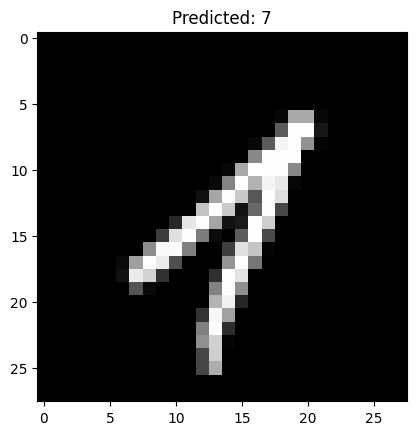

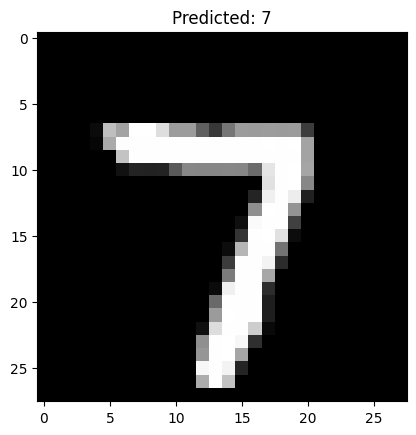

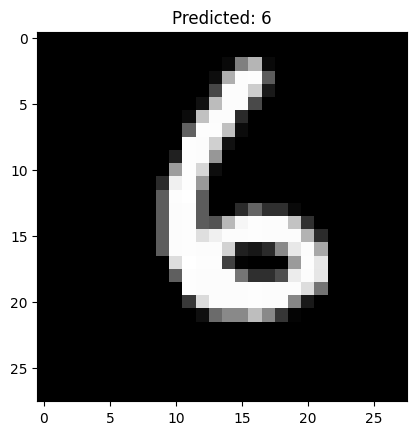

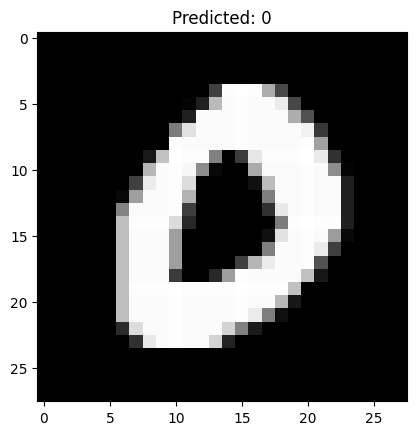

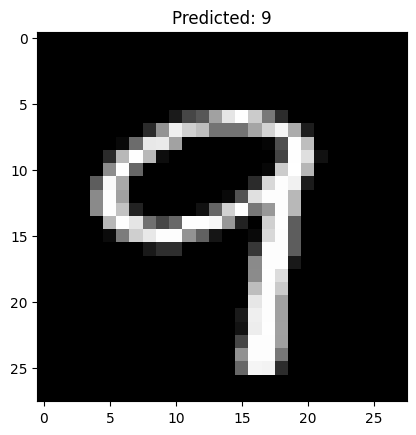

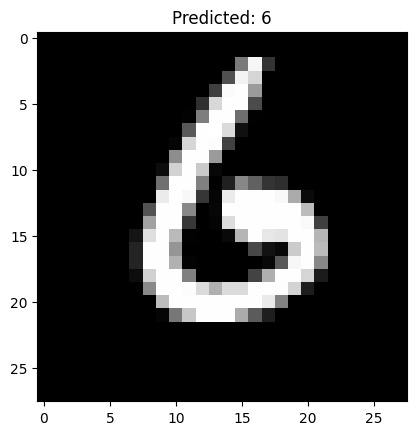

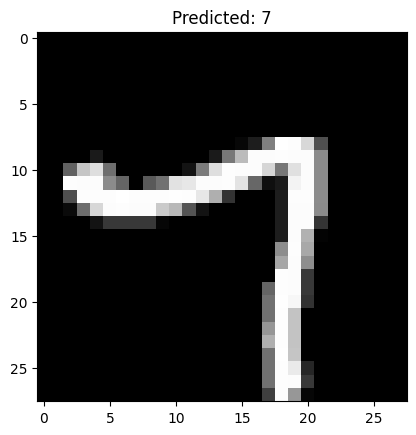

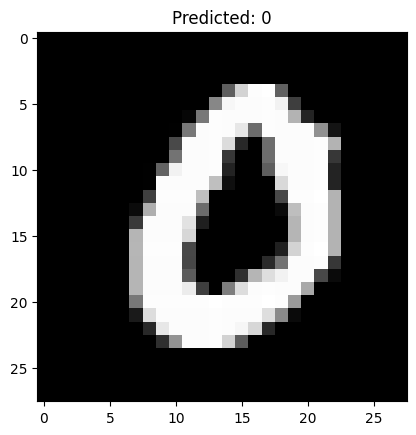

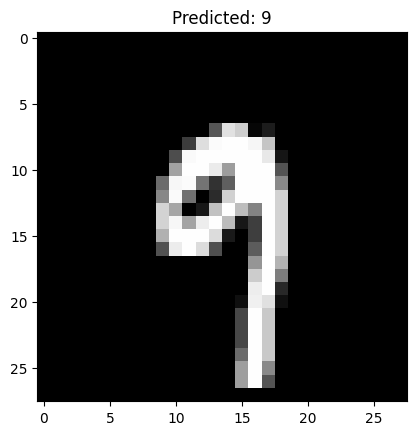

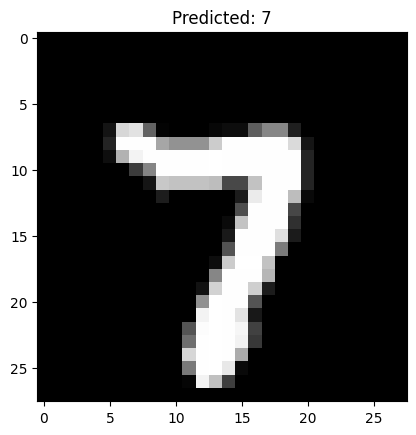

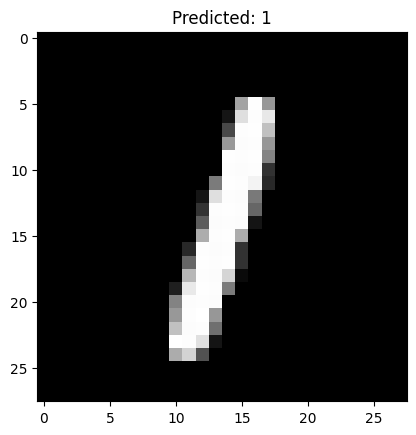

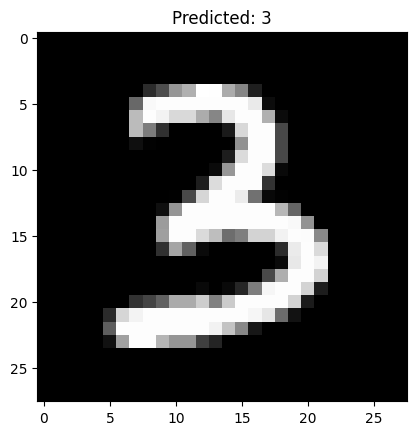

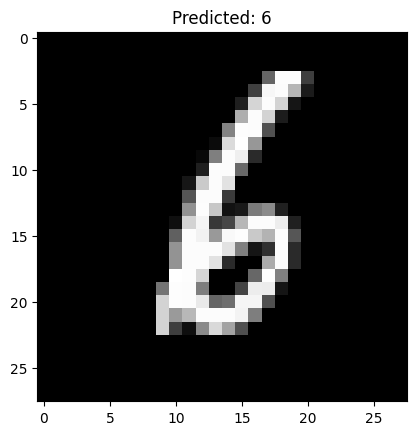

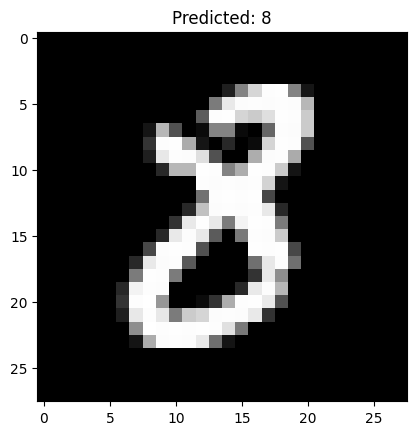

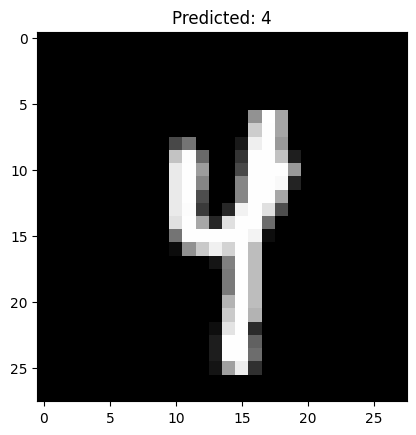

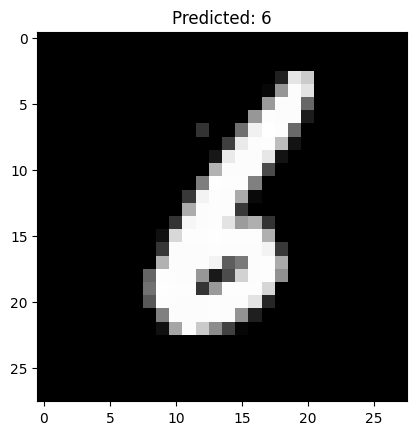

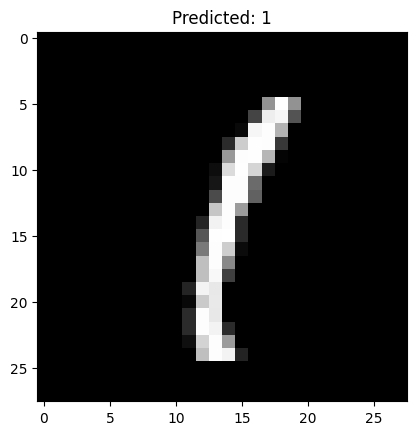

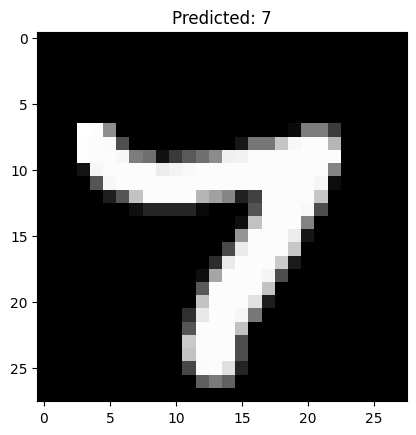

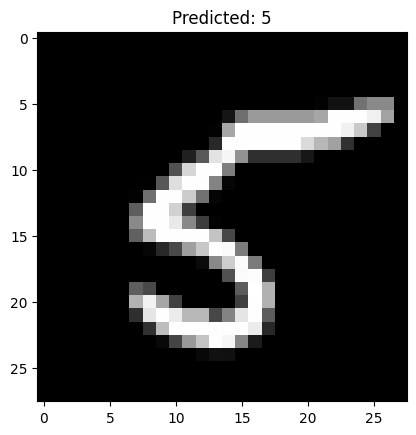

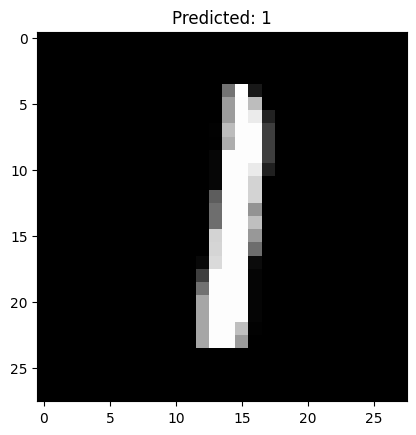

In [93]:
for i in range(120,140):
    plt.imshow(images[50000 + i], cmap = 'gray')
    plt.title(f"Predicted: {y_test_pred_classes[i]}")
    plt.show()